# Gait Analysis - Coding Activity

In this activity, you will analyze movement data collected during walking using **acceleration and EMG signals**. The goal is to apply concepts discussed in the lecture to identify gait events and examine muscle activation patterns during gait.

You will work through a sequence of steps commonly used in movement science and biomechanics research.

---

## What you will do

During this activity you will:

1. **Detect heel strike events**  
   Use the acceleration signal from a foot-mounted sensor to identify the moments when the foot contacts the ground.

2. **Segment the EMG signal into individual steps**  
   Use the detected heel strike events to divide the EMG signal into individual gait cycles.

3. **Estimate the EMG envelope**  
   Process the raw EMG signal to obtain a smoother representation of muscle activation.

4. **Normalize step duration**  
   Because each step lasts a slightly different amount of time, you will normalize each step to the same length using interpolation.

5. **Compute an ensemble average**  
   Average the EMG activity across multiple steps to reveal consistent muscle activation patterns during the gait cycle.

6. **Compare muscles**  
   Repeat the analysis for multiple muscles and examine how their activation timing differs during walking.

---

## What is expected from you

During the activity you should:

- Follow the instructions in each section and complete the missing code where indicated.
- Visualize your results at each step to verify that the analysis is working correctly.
- Discuss your observations with classmates and ask questions if something does not behave as expected.

By the end of the activity, you should have a clear understanding of how researchers:

- Identify gait events from sensor data  
- Segment biosignals into movement cycles  
- Normalize and average repeated movements to study muscle activation patterns  

These steps form the foundation for many analyses used in **biomechanics, motor control, and clinical movement research**.


## Load the data 
The file `data/GaitSample.csv` contains recordings from four Electromyography (EMG) sensors placed in the lower leg muscles: 

    - Avanti sensor 5 -> Tibialis Anterior
    - Avanti sensor 6 -> Soleus
    - Avanti sensor 7 -> Gastrocnemius Lateral 
    - Avanti sensor 8 -> Gastrocnemius Medial
    
Sensors recorded EMG data and acceleration (X,Y, and Z) data simulataneusly.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
#I will update the font size of the plot ticks. It isa personal preference
font = {'family' : 'Arial',
        'size'   : 22}

matplotlib.rc('font', **font)
import pandas as pd
from scipy import signal

data = pd.read_csv('data/GaitSample.csv')
data.head()

,X [s],Avanti sensor 5: EMG 5 [V],X [s].1,Avanti sensor 5: ACC.X 5 [g],X [s].2,Avanti sensor 5: ACC.Y 5 [g],X [s].3,Avanti sensor 5: ACC.Z 5 [g],X [s].4,Avanti sensor 6: EMG 6 [V],...,X [s].11,Avanti sensor 7: ACC.Z 7 [g],X [s].12,Avanti sensor 8: EMG 8 [V],X [s].13,Avanti sensor 8: ACC.X 8 [g],X [s].14,Avanti sensor 8: ACC.Y 8 [g],X [s].15,Avanti sensor 8: ACC.Z 8 [g]
0,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.00000,0.0,0.000000,0.0,...,0.00000,0.0,0.000000,0.0,0.00000,0.0,0.00000,0.0,0.00000,0.0
1,0.000519,0.0,0.00675,0.0,0.00675,0.0,0.00675,0.0,0.000519,0.0,...,0.00675,0.0,0.000519,0.0,0.00675,0.0,0.00675,0.0,0.00675,0.0
2,0.001038,0.0,0.01350,0.0,0.01350,0.0,0.01350,0.0,0.001038,0.0,...,0.01350,0.0,0.001038,0.0,0.01350,0.0,0.01350,0.0,0.01350,0.0
3,0.001558,0.0,0.02025,0.0,0.02025,0.0,0.02025,0.0,0.001558,0.0,...,0.02025,0.0,0.001558,0.0,0.02025,0.0,0.02025,0.0,0.02025,0.0
4,0.002077,0.0,0.02700,0.0,0.02700,0.0,0.02700,0.0,0.002077,0.0,...,0.02700,0.0,0.002077,0.0,0.02700,0.0,0.02700,0.0,0.02700,0.0


Each sensor contains 8 columns:

Time column + Measurement

For example:

Sensor 5 (Tibialis Anterior):
- X [s] → time vector
- Avanti sensor 5: EMG 5 [V] → EMG signal
- X [s].1 → time vector for acceleration x
- Avanti sensor 5: ACC.X 5 [g]
- X [s].2 → time vector for acceleration y
- Avanti sensor 5: ACC.Y 5 [g]
- X [s].3 → time vector for acceleration z
- Avanti sensor 5: ACC.Z 5 [g]

Important:
- EMG was sampled at ~2000 Hz
- Acceleration was sampled at ~240 Hz

Because of this, acceleration data only occupies part of the dataframe and the remaining rows are filled with zeros.

Text(0.5, 0, 'Time (s)')

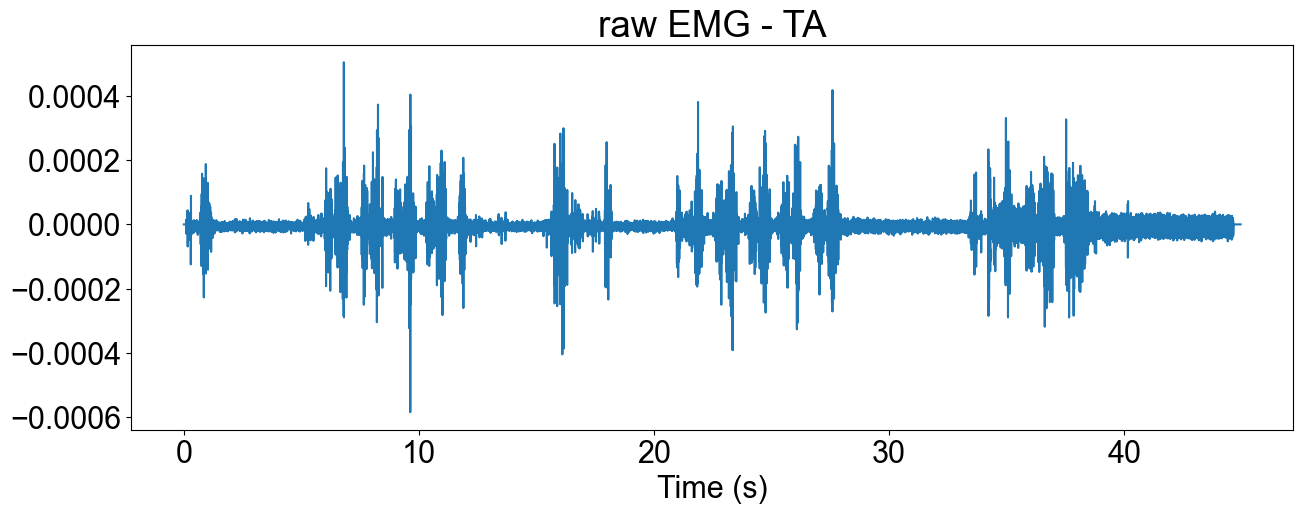

In [3]:
#plot EMG from one of the sensors
# some plots
plt.figure(figsize=(15,5))
plt.plot(data['X [s]'], data['Avanti sensor 5: EMG 5 [V]'])
plt.title('raw EMG - TA')
plt.xlabel('Time (s)')

Text(0.5, 0, 'Time (s)')

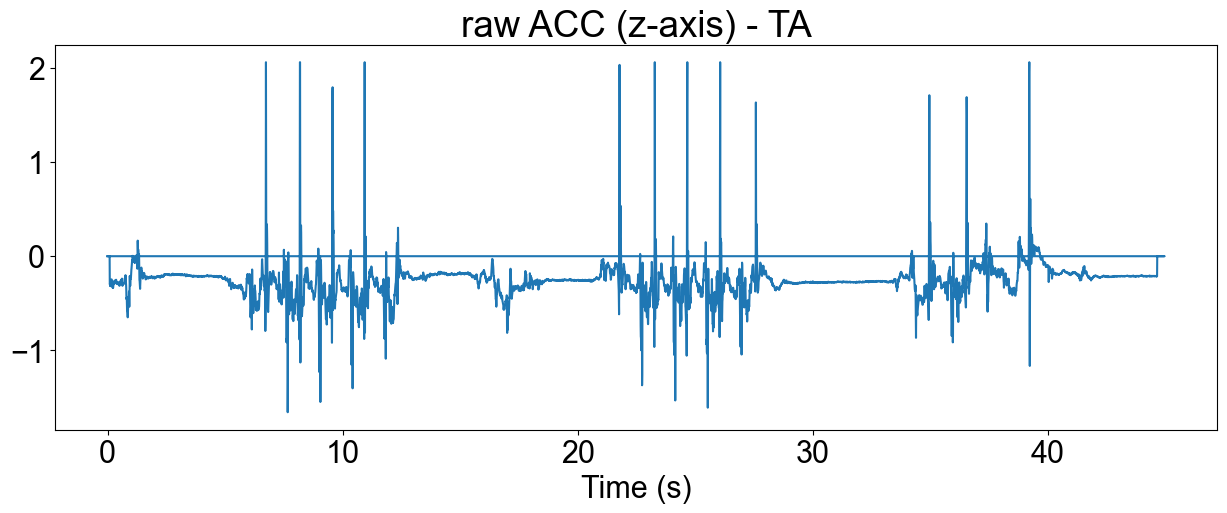

In [4]:
#plot the acceleration from one of the sensors
plt.figure(figsize=(15,5))
plt.plot(data['X [s].3'], data['Avanti sensor 5: ACC.Z 5 [g]'])
plt.title('raw ACC (z-axis) - TA')
plt.xlabel('Time (s)')

Text(0, 0.5, 'acceleration (g)')

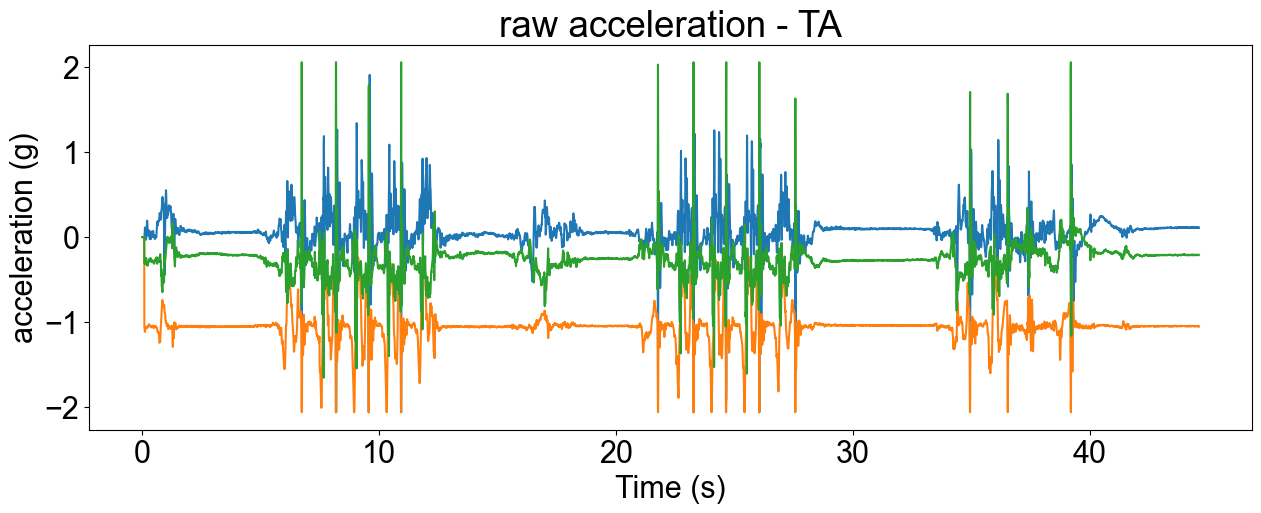

In [59]:
#plot the acceleration from one of the sensors, using the correct rows
plt.figure(figsize=(15,5))
plt.plot(data['X [s].3'].iloc[0:6610], data['Avanti sensor 5: ACC.X 5 [g]'].iloc[0:6610])
plt.plot(data['X [s].3'].iloc[0:6610], data['Avanti sensor 5: ACC.Y 5 [g]'].iloc[0:6610])
plt.plot(data['X [s].3'].iloc[0:6610], data['Avanti sensor 5: ACC.Z 5 [g]'].iloc[0:6610])
plt.title('raw acceleration - TA')
plt.xlabel('Time (s)')
plt.ylabel('acceleration (g)')

The data includes multiple gait events with 4 to 5 steps. Lets focus on one of these events

Text(0.5, 1.0, 'Magnitude acceleration')

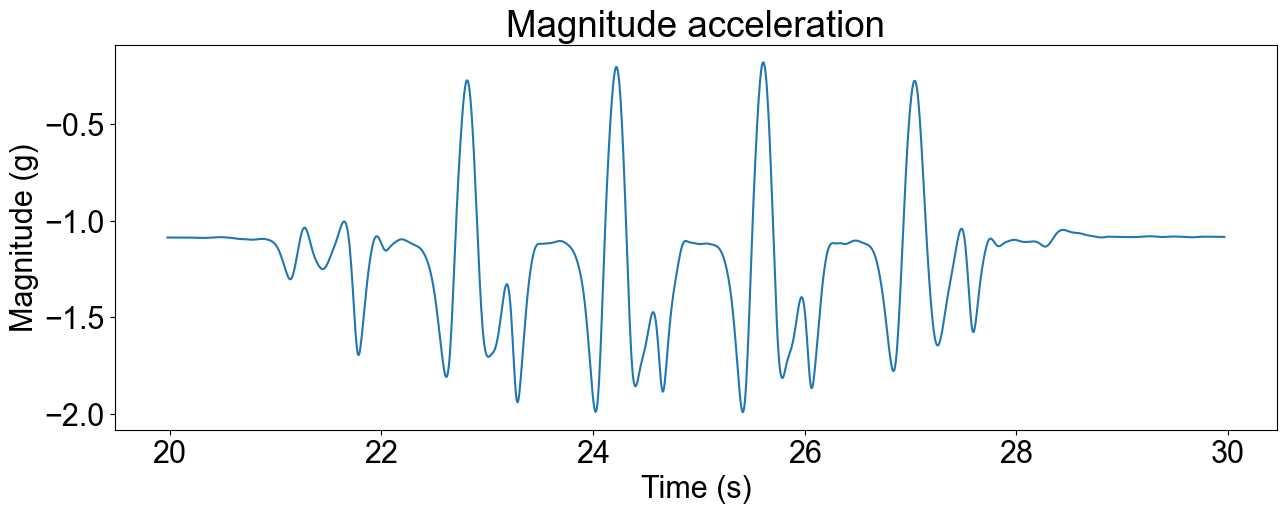

In [58]:
# focus on the first gait event - Between 20 and 30 s, and find the acceleration magnitude 
maxDuration = 6610
time_acc = data['X [s].1'][0:maxDuration].values
accx = data['Avanti sensor 6: ACC.X 6 [g]'][0:maxDuration].values
accy = data['Avanti sensor 6: ACC.Y 6 [g]'][0:maxDuration].values
accz = data['Avanti sensor 6: ACC.Z 6 [g]'][0:maxDuration].values

filterOrder = 2
cutoffFrequency = 5
SamplingFrequency = int(1/np.mean(np.diff(time_acc)))
b, a = signal.butter(filterOrder, cutoffFrequency, btype='low', analog=False, fs=SamplingFrequency)
#compute the magnitude of the acceleration
magnitude = np.sqrt(accx**2 + accy**2 + accz**2)
magnitude_filtered = signal.filtfilt(b,a,magnitude)

#take a portion of the data between 20 and 30 s
magnitude_filteredSegment = magnitude_filtered[20*SamplingFrequency:30*SamplingFrequency]
time_accSegment = time_acc[20*SamplingFrequency:30*SamplingFrequency]
plt.figure(figsize=(15,5))
plt.plot(time_accSegment, -magnitude_filteredSegment)
plt.xlabel('Time (s)')
plt.ylabel('Magnitude (g)')
plt.title('Magnitude acceleration')

This segment contains four steps.

## Activity 

### Step 1 — Detect Heel Strikes
Use the acceleration signal to detect heel strike events.

Store the indices and corresponding times of each heel strike.

Plot the acceleration signal and mark the detected heel strikes.

### Step 2 — Segment EMG Signals
Use the heel strike indices to divide the Tibialis Anterior EMG signal into individual steps.

Each step corresponds to the signal between two consecutive heel strikes.


Example:
- Step 1 = EMG between heel_strike[0] and heel_strike[1]
- Step 2 = EMG between heel_strike[1] and heel_strike[2]

Plot the EMG signals obtained for each step. 

### Step 3 — Compute EMG Envelope
Typically, we are only interested in the envelope of the EMG signals. Use the provided `processEMG()` function to compute the envelope of each EMG segment.

Plot the processed signals.

```Python
#process EMG for each segment, let's create a function that processes EMG signals

def processEMG(inputSignal,SamplingFrequency):
    #step 1- design and apply filter
    #design low-pass filter 
    filterOrder = 2
    cutoffFrequency_LP = 150
    cutoffFrequency_HP = 30
    b_LP, a_LP =  signal.butter(filterOrder, cutoffFrequency_LP, btype='low', analog=False, fs=SamplingFrequency)
    b_HP, a_HP =  signal.butter(filterOrder, cutoffFrequency_HP, btype='high', analog=False, fs=SamplingFrequency)
    #apply filter
    inputSignalFiltered = signal.filtfilt(b_HP, a_HP, signal.filtfilt(b_LP, a_LP, inputSignal))

    #step 2 - Rectification 
    inputSignalFilteredandRectified = np.maximum(0,inputSignalFiltered)
    
    #step 3 - Compute envelope
    filterOrder = 2
    cutoffFrequency_envelope = 15
    b_envelope, a_envelope =  signal.butter(filterOrder, cutoffFrequency_envelope, btype='low', analog=False, fs=SamplingFrequency)

    signalEnvelope = signal.filtfilt(b_envelope, a_envelope, inputSignalFilteredandRectified)
    
    #return signal Envelope
    return signalEnvelope 

```

We will use the EMG data (evelope) to estimate the muscle activation during each step. For this, we will average the EMG recordings from multiple steps. However, the EMG signal obtained for each step have slightly different durations and we need to use linear interpolation to ensure that all EMG segments have the same length. 

### Step 4 — Normalize Step Duration
As Each step lasts a slightly different amount of time, use linear interpolation to normalize all EMG segments to the same number of samples.


### Step 5 — Compute Ensemble Average
Compute the average EMG envelope across all steps.

Plot the result.

What does this tell you about Tibialis Anterior activation during gait?

### Step 6 — Compare Muscles
Repeat the analysis for the other three muscles.

Compare the activation timing between muscles.

Which muscle is most active near toe-off? before heel-strike?